# Weather forecasting

This notebook follows Chapter 13 of the textbook. Here we will try to predict the predict the temperature using data recorded at the Weather Station of the Max Planck Institute for Biogeochemistry in Jena, Germany. In this case we are looking at data recorded from 2009 to 2016, but if you also want to try with more updated data (and also additional data sources besides temperature), you can find it here: www.bgc-jena.mpg.de/wetter

In [1]:
import keras
import tensorflow as tf
import os
import numpy as np
from matplotlib import pyplot as plt

/Users/jakob/Desktop/Jakob/ML/ML_DL-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Download the data

- Check. Downloaded in terminal

Read the CSV file.

In [6]:
fname = os.path.join("../data/raw/jena/jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


There are 14 features in total. Let's convert them to numpy arrays and extract the temperature to a separate variable.

In [12]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

Check what the temperature looks like:

Text(0, 0.5, 'Temperature (in °C)')

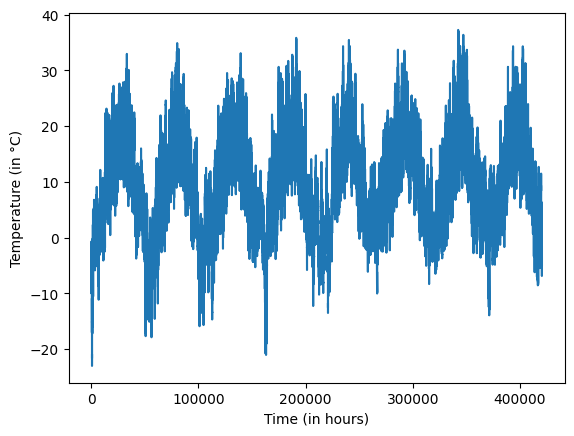

In [16]:
plt.plot(range(len(temperature)), temperature)
# print name of x- and y-axis
plt.xlabel("Time (in hours)")
plt.ylabel("Temperature (in °C)")

A lot of data points here, so make a plot that focuses on the first 10 days. There is a measurement every 10 minutes, so we get 24 × 6 = 144 data points per day.

Text(0, 0.5, 'Temperature (in °C)')

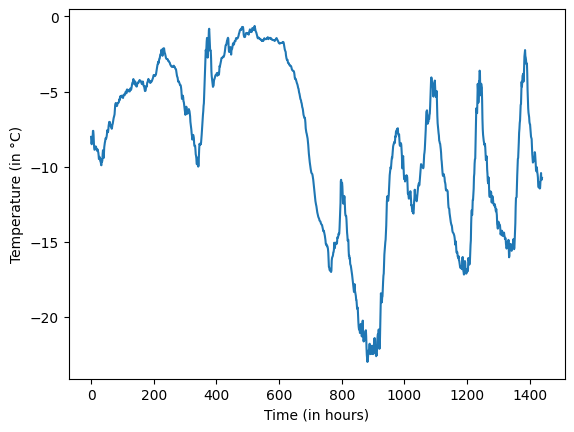

In [18]:
plt.plot(range(1440), temperature[:1440])
# print name of x- and y-axis
plt.xlabel("Time (in hours)")
plt.ylabel("Temperature (in °C)")

For our our experiments, we use the first 50% of the data for training, the following 25% for validation, and the last 25% for testing.

In [10]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


To prepare the data, we normalise it by subtracting the mean and dividing by the standard deviation.

In [11]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

This might be the most important cell in this notebook !!

It makes each feature scale to approximately
- average around 0
- standard deviation around 1

because features may have very indifferent scales


## Create the datasets to use

We’ll use `timeseries_dataset_from_array()` to instantiate three datasets: one for training, one for validation, and one for testing. We’ll use the following parameter values:

- `sampling_rate = 6`: Observations will be sampled at one data point per hour: we will only keep one data point out of 6.
- `sequence_length = 120`: Observations will go back 5 days (120 hours).
- `delay = sampling_rate * (sequence_length + 24 - 1)`: The target for a sequence will be the temperature 24 hours after the end of the sequence.



In [19]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

Try out the datasets:

In [20]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


## A simplistic model

First, for the simplest approach -- 100% autocorrelation from day to day. This means we predict the temperature 24 hours from now will be equal to the temperature right now.

In [22]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 90.26
Test MAE: 91.11


2026-03-22 02:48:18.851340: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## A fully-connected (dense) machine learning model

In [34]:
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Reshape((sequence_length * raw_data.shape[-1],))(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 7692.8413 - mae: 42.1240 - val_loss: 138.2925 - val_mae: 9.0748
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 106.9742 - mae: 8.0143 - val_loss: 150.7180 - val_mae: 11.3209
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 312.6555 - mae: 13.6166 - val_loss: 88.6339 - val_mae: 8.1577
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 144.9632 - mae: 9.2687 - val_loss: 202.3187 - val_mae: 13.7490
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 195.5376 - mae: 11.3806 - val_loss: 12.2193 - val_mae: 2.7620
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 221.3288 - mae: 10.6584 - val_loss: 101.8297 - val_mae: 9.4979
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 183.5157 - mae: 10.5800 - val_loss: 28.8229 - val_mae: 4.5278
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 164.3712 - mae: 9.8129 - val_loss: 559.2608 - val_mae: 23.4139
Epoch 9/10
819/819

Define a utility function for plotting the learning curve.

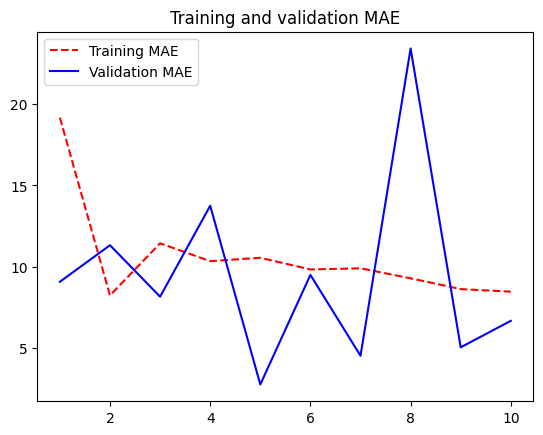

In [35]:
def plot_loss_curve(history):
    loss = history.history["mae"]
    val_loss = history.history["val_mae"]
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, "r--", label="Training MAE")
    plt.plot(epochs, val_loss, "b", label="Validation MAE")
    plt.title("Training and validation MAE")
    plt.legend()
    plt.show()

plot_loss_curve(history)

## A 1D convolutional model

Let's see how a straight-up convolutional model performs.

In [36]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 100.1216 - mae: 6.6574 - val_loss: 21.7307 - val_mae: 3.6560
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 24.2174 - mae: 3.9052 - val_loss: 25.1516 - val_mae: 3.9412
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 22.8667 - mae: 3.7879 - val_loss: 18.6279 - val_mae: 3.4124
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 20.1577 - mae: 3.5522 - val_loss: 17.5993 - val_mae: 3.3193
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 18.9445 - mae: 3.4439 - val_loss: 18.9966 - val_mae: 3.4170
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 18.2976 - mae: 3.3850 - val_loss: 16.0995 - val_mae: 3.1494
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 17.8936 - mae: 3.3501 - val_loss: 15.5057 - val_mae: 3.0981
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 17.1852 - mae: 3.2846 - val_loss: 15.1693 - val_mae: 3.0673
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━

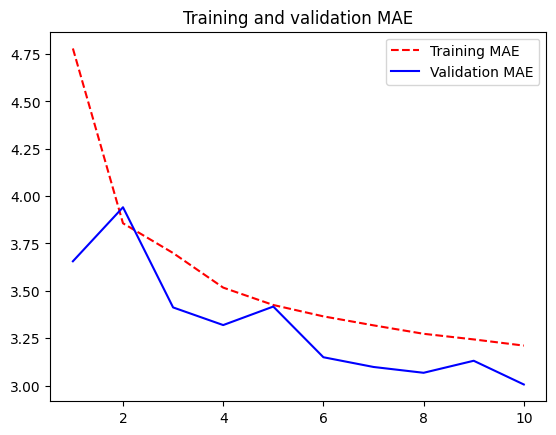

In [37]:
## Plot the loss curve for the convolutional model with updated title
plot_loss_curve(history)


## Compare to a recurrent model: LSTM

In [38]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 136.7369 - mae: 9.6203 - val_loss: 110.0071 - val_mae: 8.4935
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 99.8567 - mae: 8.0259 - val_loss: 80.9347 - val_mae: 7.1900
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 77.1426 - mae: 6.9499 - val_loss: 62.2585 - val_mae: 6.2283
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 63.2828 - mae: 6.2271 - val_loss: 50.7618 - val_mae: 5.5979
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 54.8410 - mae: 5.7482 - val_loss: 43.6841 - val_mae: 5.1696
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 49.6119 - mae: 5.4234 - val_loss: 39.2177 - val_mae: 4.8802
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 45.9420 - mae: 5.1812 - val_loss: 36.1367 - val_mae: 4.6640
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 43.2167 - mae: 4.9980 - val_loss: 33.7387 - val_mae: 4.4894
Epoch 9/10
819/819 ━━━

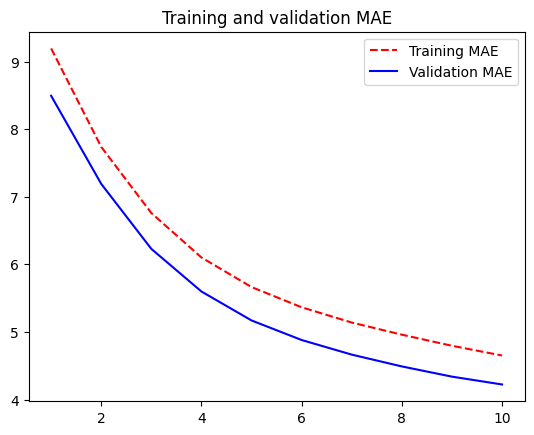

In [39]:
plot_loss_curve(history)

Maybe we need to regularise it. We add `recurrent_dropout`.

In [40]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 123.7879 - mae: 9.0999 - val_loss: 81.0687 - val_mae: 7.3695
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 86.2131 - mae: 7.5180 - val_loss: 69.0325 - val_mae: 6.8297
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 82.8886 - mae: 7.3589 - val_loss: 67.8944 - val_mae: 6.7765
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 82.5053 - mae: 7.3444 - val_loss: 67.8787 - val_mae: 6.7758
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - loss: 81.8275 - mae: 7.3097 - val_loss: 67.6056 - val_mae: 6.7629
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 81.2835 - mae: 7.2878 - val_loss: 67.4804 - val_mae: 6.7571
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 80.6168 - mae: 7.2637 - val_loss: 67.3023 - val_mae: 6.7487
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 79.8210 - mae: 7.2283 - val_loss: 67.2093 - val_mae: 6.7443
Epoch 9/50
819/819 ━━━━

## Stacked GRU

In [41]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - loss: 76.9820 - mae: 6.9906 - val_loss: 66.1274 - val_mae: 6.6933
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 65ms/step - loss: 80.4667 - mae: 7.2471 - val_loss: 65.9093 - val_mae: 6.6828
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 78.6735 - mae: 7.1777 - val_loss: 65.7764 - val_mae: 6.6764
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 78.1398 - mae: 7.1544 - val_loss: 65.7039 - val_mae: 6.6728
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 78.0795 - mae: 7.1477 - val_loss: 65.7142 - val_mae: 6.6733
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 78.0629 - mae: 7.1498 - val_loss: 65.5114 - val_mae: 6.6632
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 77.8192 - mae: 7.1387 - val_loss: 65.6661 - val_mae: 6.6710
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 63ms/step - loss: 77.6467 - mae: 7.1287 - val_loss: 65.5803 - val_mae: 6.6667
Epoch 9/50
819/819 ━━━━━

## Try a bidirectional LSTM

This one processes the input sequences twice: Once in chronological order, and once in reverse order.

Does it help in predicting our weather data?


In [42]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 126.5184 - mae: 9.2167 - val_loss: 88.9614 - val_mae: 7.7057
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - loss: 86.1656 - mae: 7.5262 - val_loss: 69.8893 - val_mae: 6.8697
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 76.9311 - mae: 7.1068 - val_loss: 66.0853 - val_mae: 6.6913
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 76.1396 - mae: 7.0649 - val_loss: 65.5971 - val_mae: 6.6675
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 76.0821 - mae: 7.0619 - val_loss: 65.5952 - val_mae: 6.6674
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 76.1288 - mae: 7.0641 - val_loss: 65.6129 - val_mae: 6.6683
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 76.0868 - mae: 7.0637 - val_loss: 65.6441 - val_mae: 6.6699
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 72.5854 - mae: 6.8643 - val_loss: 56.2555 - val_mae: 6.0958
Epoch 9/10
819/819 ━━━━

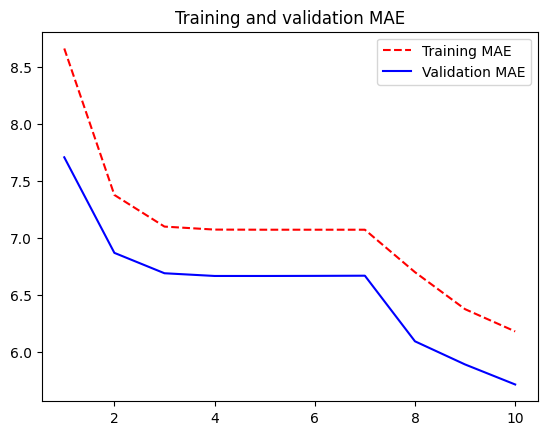

In [45]:
plot_loss_curve(history)

## Open exercises

1. Adjust the number of units in each recurrent layer in the stacked setup, as well as the amount of dropout. (The current choices are largely arbitrary and probably suboptimal.)

2. Try using a stack of Dense layers as the regressor on top of the recurrent layer, instead of a single Dense layer.

3. Improve the input to the model: try using longer or shorter sequences or a different sampling rate

4. Implement a simple [WaveNet](https://deepmind.google/discover/blog/wavenet-a-generative-model-for-raw-audio/) model -- that is, a fully convolutional network with strides larger than one, and padding set to "`causal`", so that the layers can only look backwards in time.
